In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [6]:
# Datos simples: dias transcurridos y ventas
np.random.seed(42)
dias = np.arange(1, 101)
ventas = dias * 2.5 + np.random.normal(0, 10, 100) #media=0, std=10, total=100

df = pd.DataFrame({"dia": dias, "ventas": ventas})
df.head()

,dia,ventas
0,1,7.467142
1,2,3.617357
2,3,13.976885
3,4,25.230299
4,5,10.158466


In [15]:
# 1. Separar features (X) y target (Y)
X = df[["dia"]] # lo que el modelo usa para predecir
y = df["ventas"] # lo que queremos predecir

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)}")
print(f"Datos de prueba: {len(y_test)}")

# 3. Entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Predecir
predicciones = modelo.predict(X_test)

# 5. Evaluar
error = mean_absolute_error(y_test, predicciones)
print(f"Error promedio: {error:.2f} unidades")

Datos de entrenamiento: 80
Datos de prueba: 20
Error promedio: 6.01 unidades


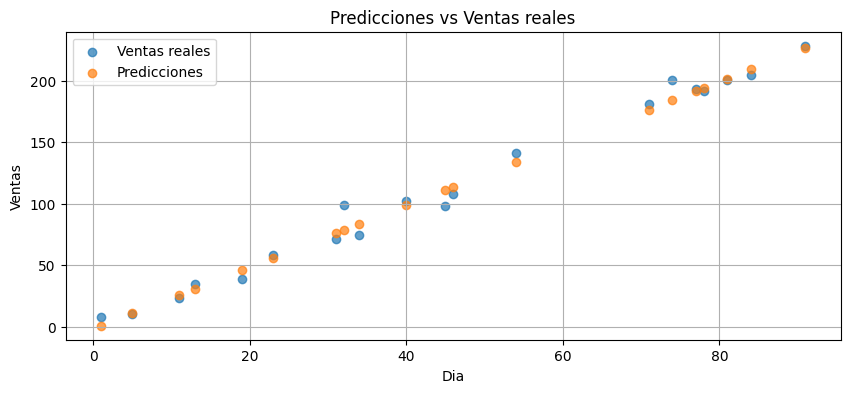

Pendiente (ventas por dia): 2.51
Intercepto: -1.81


In [20]:
import matplotlib.pyplot as plt

# Visualizar que aprendio el modelo
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Ventas reales", alpha=0.7)
plt.scatter(X_test, predicciones, label="Predicciones", alpha=0.7)
plt.title("Predicciones vs Ventas reales")
plt.xlabel("Dia")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

# Ver que encontro el modelo internamente
print(f"Pendiente (ventas por dia): {modelo.coef_[0]:.2f}")
print(f"Intercepto: {modelo.intercept_:.2f}")

/home/pulpo/miniconda3/envs/ds-journey/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/pulpo/miniconda3/envs/ds-journey/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


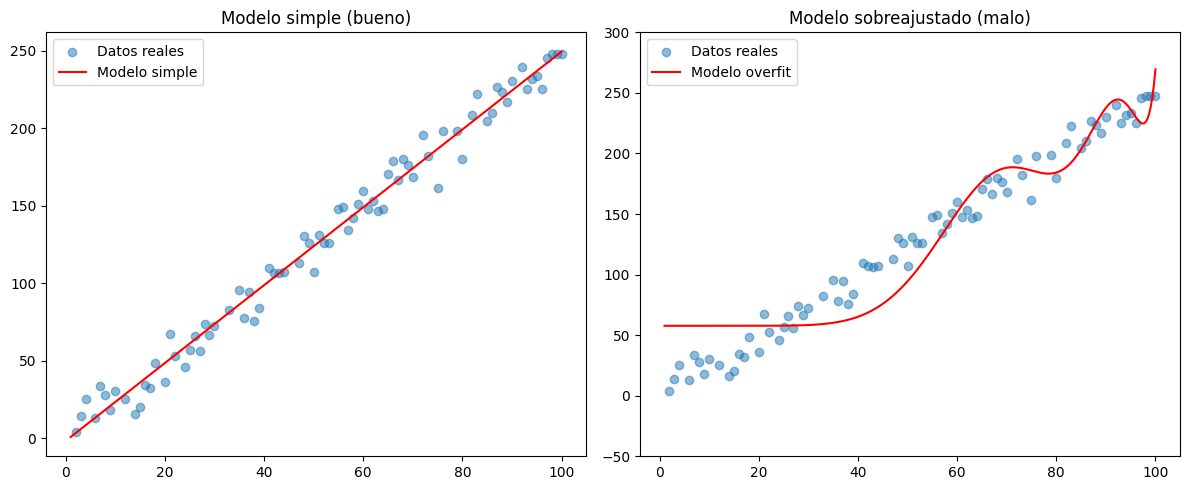

Error modelo simple: 6.01
Error modelo overfit: 21.53


In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Modelo simple (lo que ya tienes) — generaliza bien
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

# Modelo sobreajustado — memoriza los datos de entrenamiento
modelo_overfit = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
modelo_overfit.fit(X_train, y_train)

# Comparar errores
dias_ordenados = np.linspace(1, 100, 300).reshape(-1, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.5, label="Datos reales")
plt.plot(dias_ordenados, modelo_simple.predict(dias_ordenados), color='red', label="Modelo simple")
plt.title("Modelo simple (bueno)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, alpha=0.5, label="Datos reales")
plt.plot(dias_ordenados, modelo_overfit.predict(dias_ordenados), color='red', label="Modelo overfit")
plt.ylim(-50, 300)
plt.title("Modelo sobreajustado (malo)")
plt.legend()

plt.tight_layout()
plt.show()

# Error en datos de prueba (datos que nunca vio)
print(f"Error modelo simple: {mean_absolute_error(y_test, modelo_simple.predict(X_test)):.2f}")
print(f"Error modelo overfit: {mean_absolute_error(y_test, modelo_overfit.predict(X_test)):.2f}")